In [1]:
import os
import csv
import ast
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import matplotlib as mpl

import sys
sys.path.insert(0, str(Path("..").resolve()))
from utils import savefig

plt.rcParams['font.size'] = 14

mpl.rcParams['svg.fonttype'] = 'none'
save_fig = True

In [2]:
gamma_names = ["0", "02", "04", "06", "08", "10"]
temporal_discount_factors = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
noise_levels = [0, 0.2, 0.4, 0.6, 0.8, 1]
noise_names = ["0", "02", "04", "06", "08", "1"]
colormap = np.array(["#2A9D8F", "#E9C46A", "#E76F51", "#F4A261", "#264653"]) 

In [3]:
df = pd.read_pickle("./data/df_models.pkl")
df_filtered = pd.read_pickle("./data/df_filtered_cluster.pkl")
df_reservoir = pd.read_pickle("./data/df_reservoir.pkl")
df_tcm = pd.read_pickle("./data/df_tcm.pkl")
df_perf = pd.read_pickle("./data/df_perf.pkl")
df_perf_cluster = pd.read_pickle("./data/df_perf_cluster.pkl")

### performance of all models colored with clusters

In [4]:
# plot scatter with cluster labels

def plot_scatter_cluster(df, x, y, c, x_label, y_label, fit=True, plot_reservoir=True, save_folder=None, save_name=None):
    plt.figure(figsize=(3.6, 3.3), dpi=200)

    plt.scatter(df[x], df[y], c=colormap[df[c].iloc[:]], alpha=0.5)

    if fit:
        if plot_reservoir:
            # plot for reservoir and tcm
            plt.scatter(df_reservoir[x], df_reservoir[y], c=colormap[-1], alpha=0.5)
            # plt.scatter(df_tcm[x], df_tcm[y], c=colormap[-1])
    
        # Reshape x and y for sklearn
        x_reshaped = np.array(df[x]).reshape(-1, 1)
        y_reshaped = np.array(df[y]).reshape(-1, 1)

        # Fit linear regression model
        model = LinearRegression()
        model.fit(x_reshaped, y_reshaped)

        # Predict y values
        sorted_x_idx = np.argsort(x_reshaped.reshape(-1))
        x1, x2 = x_reshaped[sorted_x_idx[0]], x_reshaped[sorted_x_idx[-1]]
        y_pred = model.predict(x_reshaped)
        y1, y2 = y_pred[sorted_x_idx[0]], y_pred[sorted_x_idx[-1]]

        # Calculate R-squared
        r2 = r2_score(y_reshaped, y_pred)
        # Calculate the p-value for the regression
        _, p_value = stats.pearsonr(x_reshaped.flatten(), y_reshaped.flatten())
        
        # Plot the regression line
        plt.plot([x1, x2], [y1, y2], color="grey")

        x_label = x_label # +"\n(R² = {:.2f}, p = {:.3f})".format(r2, p_value)
        print("freedom:", x_reshaped.shape[0]-2, "r2: ", r2, "p_value: ", p_value)

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.xlabel(x_label)
    plt.ylabel(y_label)

    plt.tight_layout()

    if save_fig and save_folder and save_name:
        savefig(save_folder, save_name, format="svg", close=False)

    # plt.tight_layout()
    plt.show()


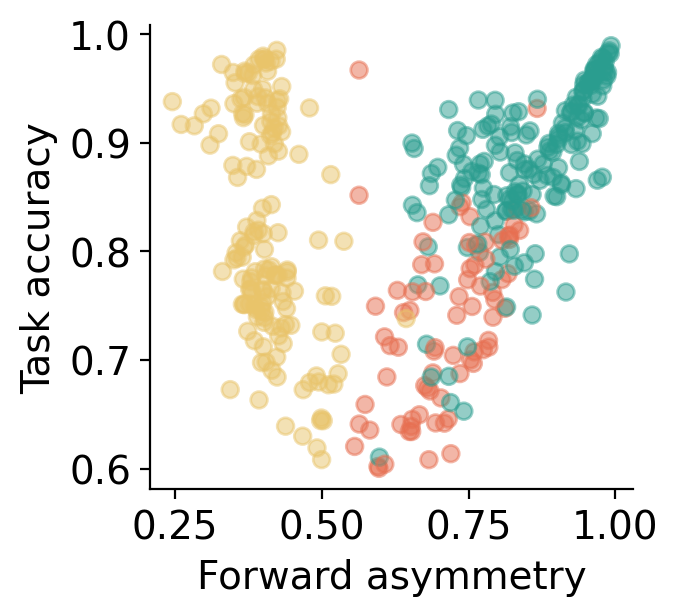

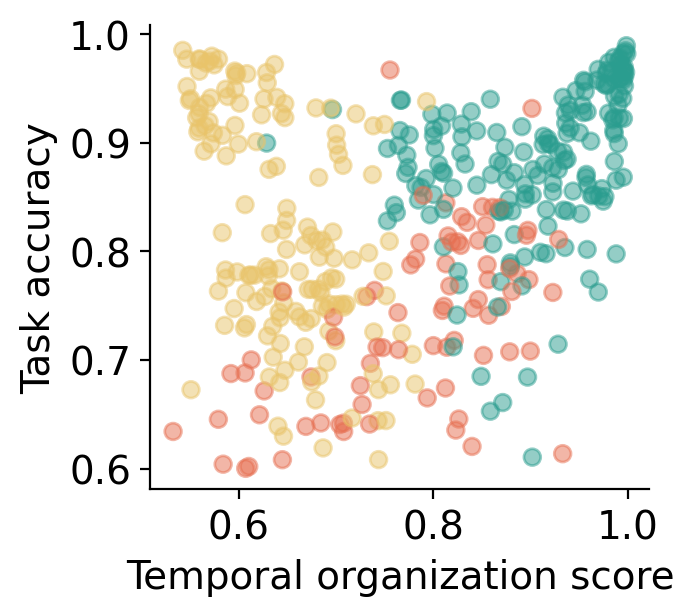

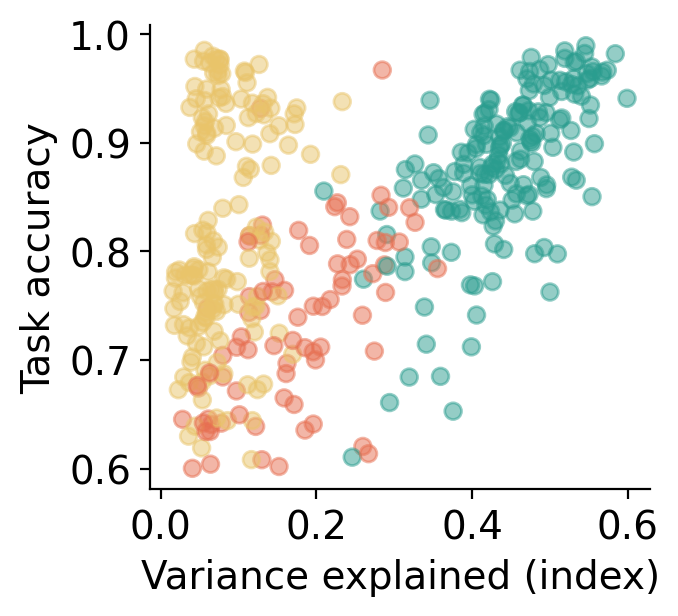

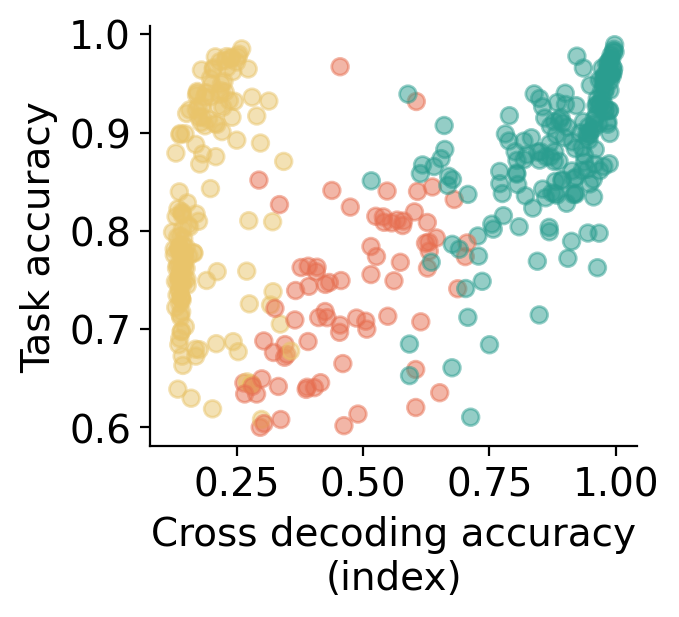

In [17]:
plot_scatter_cluster(df_filtered, 'forward_asymmetry', 'accuracy', 'cluster', 'Forward asymmetry', 'Task accuracy', fit=False,
                    save_folder="./figures/supp4", save_name="suppfig4A")
plot_scatter_cluster(df_filtered, 'temporal_factor', 'accuracy', 'cluster', 'Temporal organization score', 'Task accuracy', fit=False,
                    save_folder="./figures/supp4", save_name="suppfig4B")
plot_scatter_cluster(df_filtered, 'explained_variance_index', 'accuracy', 'cluster', 'Variance explained (index)', 'Task accuracy', fit=False,
                    save_folder="./figures/supp4", save_name="suppfig4C")
plot_scatter_cluster(df_filtered, 'cross_decoding_accuracy_index', 'accuracy', 'cluster', 'Cross decoding accuracy\n(index)', 'Task accuracy', fit=False,
                    save_folder="./figures/supp4", save_name="suppfig4D")

172
155
78


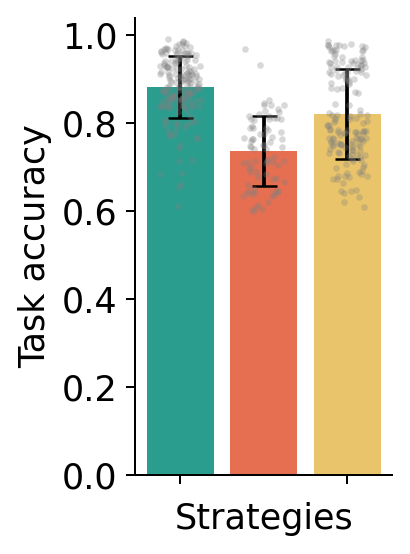

In [7]:
# performance of each strategy

# df_tdf_filtered = df_filtered[(df_filtered["noise_level"] == 1.0) & (df_filtered["temporal_factor"] >= 0.4)]

df_grouped_by_cluster = df_filtered.groupby("cluster")

accuracy = df_grouped_by_cluster["accuracy"].mean()

accuracy_std = df_grouped_by_cluster["accuracy"].std()

accuracy_data = []
for _, group in df_grouped_by_cluster:
    accuracy_data.append(group["accuracy"].to_numpy())



plt.figure(figsize=(2.5, 3.3), dpi=180)
# plt.bar(accuracy.index, accuracy.values[[1,2,0]], color=colormap[accuracy.index[[1,2,0]]], yerr=accuracy_std.values[[1,2,0]], capsize=5)
plt.bar(accuracy.index, accuracy.values[[0,2,1]], color=colormap[accuracy.index[[0,2,1]]], yerr=accuracy_std.values[[0,2,1]], capsize=5)
# Plot individual data points as small grey dots with jitter on top of the bar plot
locs = [0,2,1]
for i, group_data in enumerate(accuracy_data):
    x_vals = np.random.uniform(low=locs[i]-0.25, high=locs[i]+0.25, size=len(group_data))
    plt.scatter(x_vals, group_data, color='grey', s=7, alpha=0.3, zorder=4, linewidths=0)
    print(len(group_data))


# # Create the violin plot
# parts = plt.violinplot(
#     accuracy_data,
#     showmeans=False,
#     showmedians=False,
#     widths=0.6,
#     showextrema=False,
# )
# # Apply colormap coloring to each violin
# for i, pc in enumerate(parts['bodies']):
#     color = colormap[i]
#     pc.set_facecolor(color)
#     pc.set_edgecolor(color)
#     pc.set_alpha(1.0)
# # Calculate median and quantiles for each group
# medians = [np.median(acc) for acc in accuracy_data]
# q1s = [np.percentile(acc, 25) for acc in accuracy_data]
# q3s = [np.percentile(acc, 75) for acc in accuracy_data]
# # Plot median as a white dot and quantiles as black lines (no blue lines from min to max)
# positions = np.arange(1, len(accuracy_data) + 1)
# for pos, median, q1, q3 in zip(positions, medians, q1s, q3s):
#     plt.scatter(pos, median, color="white", edgecolor='black', zorder=5, s=30)
#     plt.plot([pos, pos], [q1, q3], color='black', linewidth=2, zorder=4)
# plt.ylim(0, 1)


# # Example colormap for 3 clusters, adjust as needed
# box_colors = [colormap[0], colormap[2], colormap[1]]
# bp = plt.boxplot(
#     accuracy_data,
#     labels=["Strategy 1", "Strategy 2", "Strategy 3"],
#     showfliers=False,
#     patch_artist=True, # enables coloring the boxes
#     boxprops=dict(linewidth=0) # removes black boundary by setting linewidth to 0
# )
# # Color the boxes
# for patch, color in zip(bp['boxes'], box_colors):
#     patch.set_facecolor(color)
#     patch.set_edgecolor(color)  # To remove edge color (same as fill)
# # Set median to black
# for median in bp['medians']:
#     median.set_color('black')
#     median.set_linewidth(2)
# plt.ylim(0, 1)

ax = plt.gca()
ax.set_xticklabels([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel("Strategies")
plt.ylabel("Task accuracy")

plt.tight_layout()
if save_fig:
    savefig("./figures/fig2", "fig2D", format="svg", close=False)

plt.show()






### plot for the performance dataset

In [12]:
df_perf_cluster_filtered = df_perf_cluster[df_perf_cluster["accuracy"] > 0.4].copy()


freedom: 81 r2:  0.7091433586576537 p_value:  1.985491887019521e-23


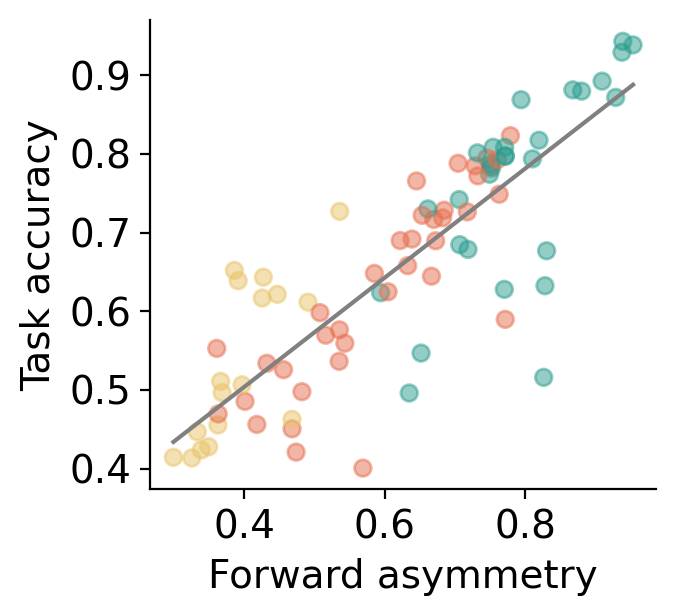

freedom: 81 r2:  0.4557784325404777 p_value:  2.5695389453607654e-12


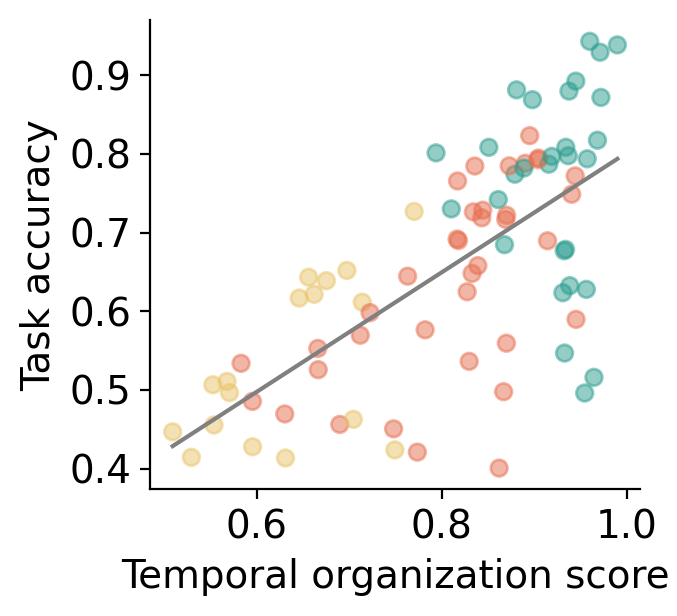

freedom: 81 r2:  0.5131524236299438 p_value:  2.665739610342993e-14


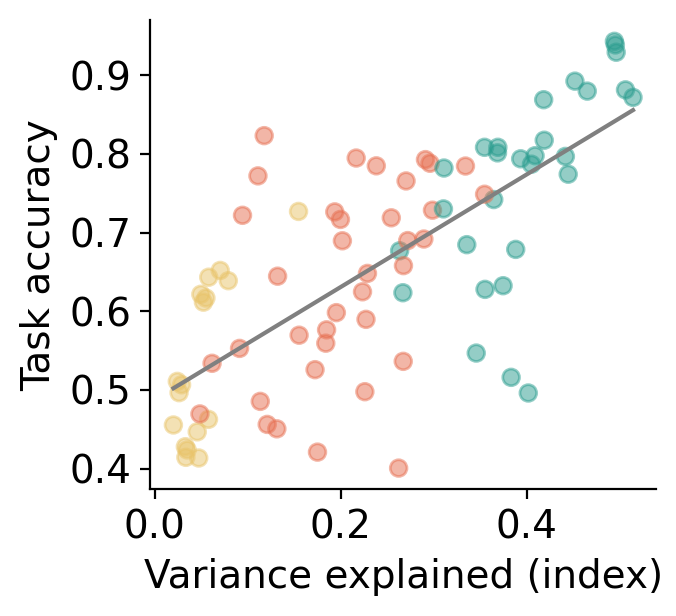

freedom: 81 r2:  0.379217401206732 p_value:  5.79129109365912e-10


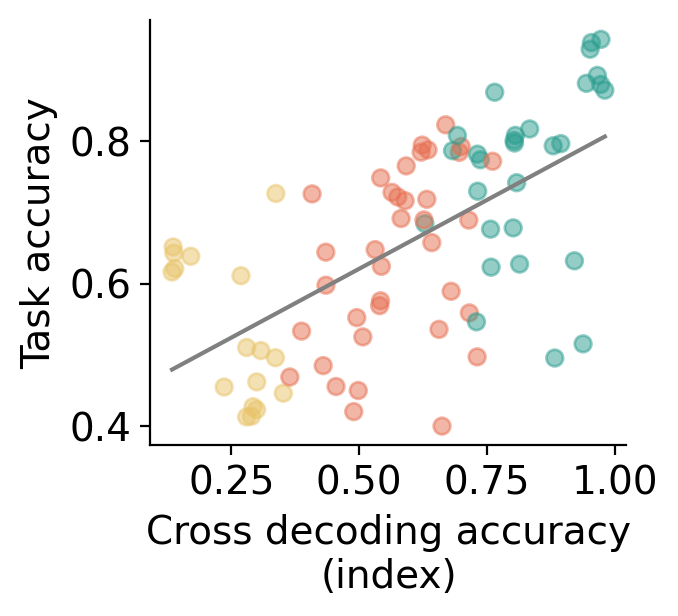

In [13]:
plot_scatter_cluster(df_perf_cluster_filtered, 'forward_asymmetry', 'accuracy', 'cluster', 'Forward asymmetry', 'Task accuracy', fit=True, plot_reservoir=False,
                    save_folder="./figures/exfig4", save_name="exfig4A")
plot_scatter_cluster(df_perf_cluster_filtered, 'temporal_factor', 'accuracy', 'cluster', 'Temporal organization score', 'Task accuracy', fit=True, plot_reservoir=False,
                    save_folder="./figures/exfig4", save_name="exfig4B")
plot_scatter_cluster(df_perf_cluster_filtered, 'explained_variance_index', 'accuracy', 'cluster', 'Variance explained (index)', 'Task accuracy', fit=True, plot_reservoir=False,
                    save_folder="./figures/exfig4", save_name="exfig4C")
plot_scatter_cluster(df_perf_cluster_filtered, 'cross_decoding_accuracy_index', 'accuracy', 'cluster', 'Cross decoding accuracy\n(index)', 'Task accuracy', fit=True, plot_reservoir=False,
                    save_folder="./figures/exfig4", save_name="exfig4D")


[30, 29, 41]
30
29
41


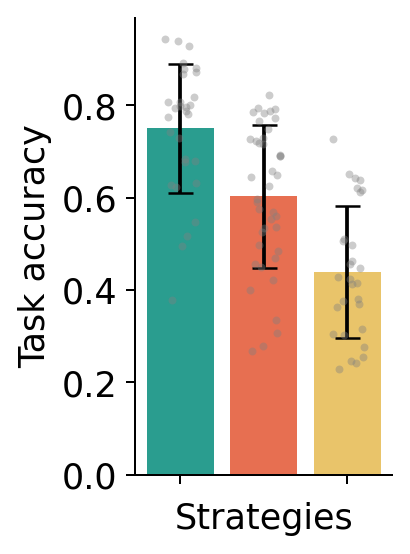

In [11]:
# performance of each strategy

# df_tdf_filtered = df_filtered[(df_filtered["noise_level"] == 1.0) & (df_filtered["temporal_factor"] >= 0.4)]

df_grouped_by_cluster = df_perf_cluster_filtered.groupby("cluster")

accuracy = df_grouped_by_cluster["accuracy"].mean()

accuracy_std = df_grouped_by_cluster["accuracy"].std()

accuracy_data = []
for _, group in df_grouped_by_cluster:
    accuracy_data.append(group["accuracy"].to_numpy())
print([len(group) for group in accuracy_data])


plt.figure(figsize=(2.5, 3.3), dpi=180)
plt.bar(accuracy.index, accuracy.values[[0,2,1]], color=colormap[accuracy.index[[0,2,1]]], yerr=accuracy_std.values[[0,2,1]], capsize=5)
locs = [0,2,1]
for i, group_data in enumerate(accuracy_data):
    x_vals = np.random.uniform(low=locs[i]-0.2, high=locs[i]+0.2, size=len(group_data))
    plt.scatter(x_vals, group_data, color='grey', s=10, alpha=0.4, zorder=4, linewidths=0)
    print(len(group_data))
ax = plt.gca()
ax.set_xticklabels([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel("Strategies")
plt.ylabel("Task accuracy")

plt.tight_layout()
if save_fig:
    savefig("./figures/fig4", "fig4A", format="svg", close=False)

plt.show()






### perturbation analysis

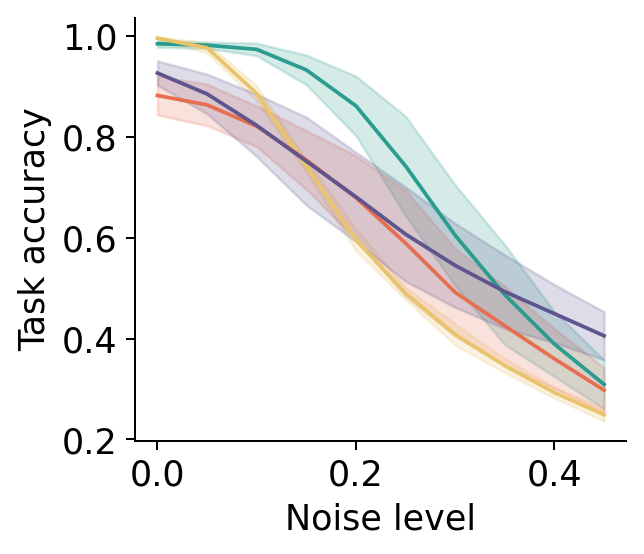

In [22]:
# df_filtered_new = df_filtered[df_filtered["accuracy"] > 0.9]
# Get the 10 models with the highest accuracy for each cluster
top_models_per_cluster = {}

for cluster_id in range(3):
    # Filter the models belonging to the current cluster
    cluster_models = df_filtered[df_filtered["cluster"] == cluster_id]
    
    # Sort the models by accuracy in descending order
    sorted_models = cluster_models.sort_values(by="accuracy", ascending=False)
    
    # Select the top 10 models
    top_models = sorted_models.head(10)
    
    # Store the result in the dictionary
    top_models_per_cluster[cluster_id] = top_models

# Convert the dictionary of top models per cluster into a DataFrame
top_models_df = pd.concat(top_models_per_cluster.values(), keys=top_models_per_cluster.keys(), names=['cluster_id', 'model_index']).reset_index(level='model_index', drop=True).reset_index()

df_filtered_new = top_models_df

perturbation_data = [[] for i in range(3)]
for i in range(3):
    perturbation_data[i] = df_filtered_new[df_filtered_new["cluster"] == i]["perturbation_accuracy"].to_numpy()
    perturbation_data[i] = np.stack(perturbation_data[i])

perturbation_data_mean = [np.mean(perturbation_data[i], axis=0) for i in range(3)]
perturbation_data_std = [np.std(perturbation_data[i], axis=0) for i in range(3)]

perturbation_data_tcm = df_tcm["perturbation_accuracy"].to_numpy()
perturbation_data_tcm = np.stack(perturbation_data_tcm)
perturbation_data_tcm_mean = np.mean(perturbation_data_tcm, axis=0)
perturbation_data_tcm_std = np.std(perturbation_data_tcm, axis=0)

plt.figure(figsize=(3.8, 3.3), dpi=180)
xaxis = np.linspace(0, 1, 21)
plt.plot(xaxis[:10], perturbation_data_mean[0][:10], color=colormap[0], label="Cluster 0")
plt.fill_between(xaxis[:10], perturbation_data_mean[0][:10] - perturbation_data_std[0][:10], perturbation_data_mean[0][:10] + perturbation_data_std[0][:10], color=colormap[0], alpha=0.2)
plt.plot(xaxis[:10], perturbation_data_mean[1][:10], color=colormap[1], label="Cluster 1")
plt.fill_between(xaxis[:10], perturbation_data_mean[1][:10] - perturbation_data_std[1][:10], perturbation_data_mean[1][:10] + perturbation_data_std[1][:10], color=colormap[1], alpha=0.2)
plt.plot(xaxis[:10], perturbation_data_mean[2][:10], color=colormap[2], label="Cluster 2")
plt.fill_between(xaxis[:10], perturbation_data_mean[2][:10] - perturbation_data_std[2][:10], perturbation_data_mean[2][:10] + perturbation_data_std[2][:10], color=colormap[2], alpha=0.2)
plt.plot(xaxis[:10], perturbation_data_tcm_mean[:10], color="#5E548E", label="TCM")
plt.fill_between(xaxis[:10], perturbation_data_tcm_mean[:10] - perturbation_data_tcm_std[:10], perturbation_data_tcm_mean[:10] + perturbation_data_tcm_std[:10], color="#5E548E", alpha=0.2)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel("Noise level")
plt.ylabel("Task accuracy")

plt.tight_layout()
if save_fig:
    savefig("./figures/fig4", "fig4B", format="svg", close=False)

plt.show()




### working memory noise and strategy

In [23]:
df_no_noise = df[df["wm_noise"] == 0.0].copy()
df_less_noise = df[df["wm_noise"] == 0.04].copy()
df_large_noise = df[df["wm_noise"] == 0.1].copy()

159 194 196


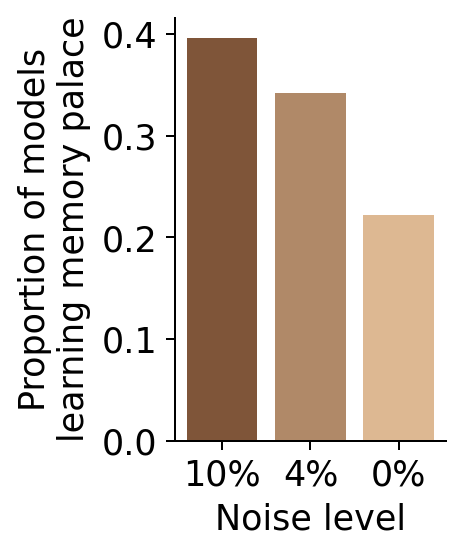

In [24]:
# df_no_noise_filtered = df_no_noise[(df_no_noise["accuracy"] > 0.7) & (df_no_noise["temporal_factor"] >= 0.37)]
# df_filtered = df[(df["accuracy"] > 0.7) & (df["temporal_factor"] >= 0.44)]
df_no_noise_filtered = df_no_noise[((df_no_noise["temporal_discount_factor"] == 1.0) | (df_no_noise["noise_level"] == 1.0)) & (df_no_noise["accuracy"] >= 0.7)]
df_less_noise_filtered = df_less_noise[((df_less_noise["temporal_discount_factor"] == 1.0) | (df_less_noise["noise_level"] == 1.0)) & (df_less_noise["accuracy"] >= 0.7)]
df_large_noise_filtered = df_large_noise[((df_large_noise["temporal_discount_factor"] == 1.0) | (df_large_noise["noise_level"] == 1.0)) & (df_large_noise["accuracy"] >= 0.7)]
print(len(df_large_noise_filtered), len(df_no_noise_filtered), len(df_less_noise_filtered))

num_memory_palace_large_noise = len((df_large_noise_filtered[(df_large_noise_filtered["explained_variance_index"] >= 0.4)]))
prop_memory_palace_large_noise = num_memory_palace_large_noise / len(df_large_noise_filtered)

num_memory_palace_no_noise = len((df_no_noise_filtered[(df_no_noise_filtered["explained_variance_index"] >= 0.4)]))
prop_memory_palace_no_noise = num_memory_palace_no_noise / len(df_no_noise_filtered)

num_memory_palace_less_noise = len((df_less_noise_filtered[(df_less_noise_filtered["explained_variance_index"] >= 0.4)]))
prop_memory_palace_less_noise = num_memory_palace_less_noise / len(df_less_noise_filtered)

plt.figure(figsize=(2.8, 3.3), dpi=180)
plt.bar(0, prop_memory_palace_large_noise, color="#7F5539")
plt.bar(1, prop_memory_palace_less_noise, color="#B08968")
plt.bar(2, prop_memory_palace_no_noise, color="#DDB892")


plt.xticks([0, 1, 2], ["10%", "4%", "0%"])
plt.xlabel("Noise level")
# plt.ylabel("Proportion of explained\nvariance of index > 0.4")
plt.ylabel("Proportion of models\nlearning memory palace")
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
if save_fig:
    savefig("./figures/fig4", "fig4C", format="svg", close=False)

plt.show()